# Temperature Predictor

**Author:** Lab of Farm Structures
**Date:** 2026-04

## Install and Import necessary libraries

In [8]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar
from jaqpotpy.models.xgboost import XGBoostModel

# Upload Thermal data and create DataFrame

In [120]:
model_test = 'mclPHA_data_new'

df_test = pd.read_csv(f'{model_test}.csv')

In [121]:
# Check DataFrame
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   scl_pha_ratio_mol                    431 non-null    float64
 1   3hb_ratio_mol                        431 non-null    float64
 2   3hv_ratio_mol                        431 non-null    float64
 3   mcl_pha_ratio_mol                    431 non-null    float64
 4   3hhx_ratio_mol                       426 non-null    float64
 5   3hhp_ratio_mol                       431 non-null    float64
 6   3ho_ratio_mol                        431 non-null    float64
 7   3hn_ratio_mol                        431 non-null    float64
 8   3hd_ratio_mol                        426 non-null    float64
 9   3hud_ratio_mol                       431 non-null    float64
 10  3hdd_ratio_mol                       430 non-null    float64
 11  3htrid_ratio_mol                

## Select target value (Tm1, Tc1, Tg1) and feature set

In [122]:
df_test = df_test.rename(columns={"tm_mean": "tm"})

In [37]:
df_test['log_mw'] = np.log10(df_test['mw'])

In [38]:
# Base features (common to all cases)
base_features = [
    'scl_pha_ratio_mol',
    'mcl_pha_ratio_mol',
#    'additive1_type',
    'additive1_percentage_wt',
    '3hb_ratio_mol',
    '3hhx_ratio_mol',
    'log_mw',
    '3ho_ratio_mol'
#    'crystallinity'
#    'additive2_type',
 #   'additive2_percentage_wt'
]

# Choose target
target = 'tm'   # 'tm1', 'tc1', or 'tg1'
measure_unit = 'Celsius'

# Conditional feature selection
if target == 'tm':
    features = base_features  + ['tg1']

elif target == 'tc1':
    features = base_features

elif target == 'tg1':
    features = base_features + ['tm1'] + ['tc1']

else:
    raise ValueError(f"Unsupported target: {target}")

# Output for verification
print("Target:", target)
print("Features:", features)

Target: tm
Features: ['scl_pha_ratio_mol', 'mcl_pha_ratio_mol', 'additive1_percentage_wt', '3hb_ratio_mol', '3hhx_ratio_mol', 'log_mw', '3ho_ratio_mol', 'tg1']


In [39]:
# Create DataFrame
df_new = df_test[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245 entries, 1 to 428
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   scl_pha_ratio_mol        245 non-null    float64
 1   mcl_pha_ratio_mol        245 non-null    float64
 2   additive1_percentage_wt  245 non-null    float64
 3   3hb_ratio_mol            245 non-null    float64
 4   3hhx_ratio_mol           245 non-null    float64
 5   log_mw                   245 non-null    float64
 6   3ho_ratio_mol            245 non-null    float64
 7   tg1                      245 non-null    float64
 8   tm                       245 non-null    float64
dtypes: float64(9)
memory usage: 19.1 KB


In [40]:
df_final = df_final[df_final["mcl_pha_ratio_mol"] <= 100].copy()

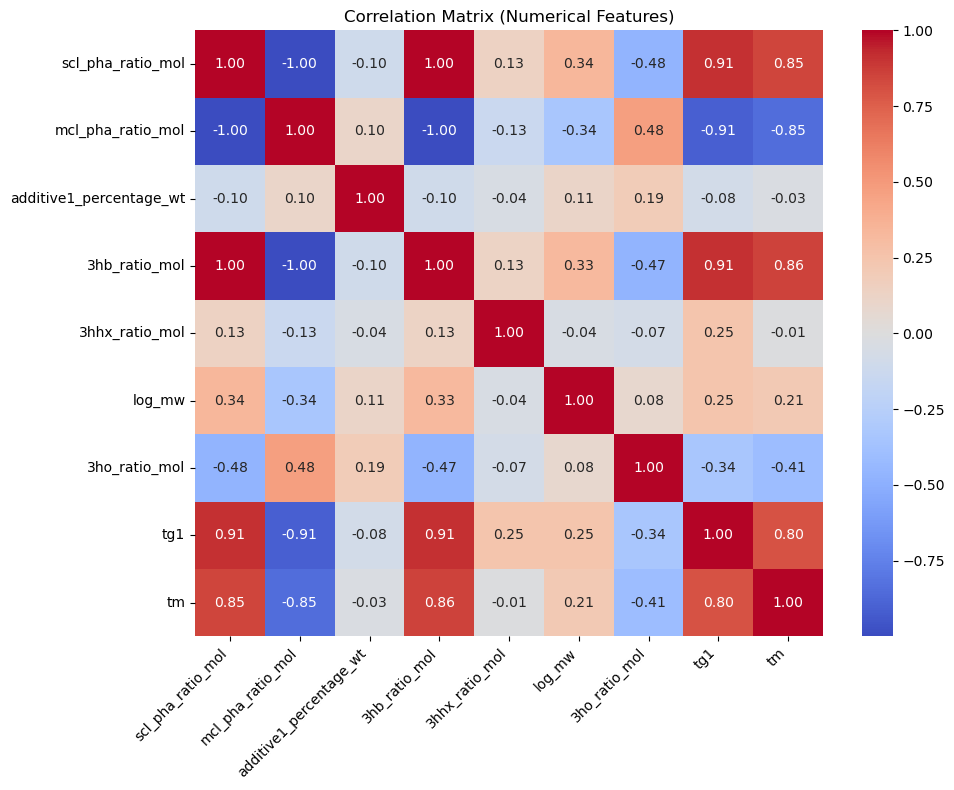

In [41]:
# numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = df_final.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

## Train - test splitting

In [42]:
# Separate features and target
drop_cols = [target, 'scl_pha_ratio_mol','3hb_ratio_mol']

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"Train set size: {X_train.shape}\n"
    f"Test set size:  {X_test.shape}"
)

Train set size: (182, 6)
Test set size:  (46, 6)


In [44]:
X_train_final = X_train.copy()
X_test_final = X_test.copy()

# ── Domain of Applicability (DoA) bounds from training data ──────────────────
numerical_cols = X_train_final.select_dtypes(include=[np.number]).columns.tolist()

doa_bounds = pd.DataFrame({
    'min': X_train_final[numerical_cols].min(),
    'max': X_train_final[numerical_cols].max(),
})

print("Domain of Applicability — Training Set Bounds")
print(doa_bounds.to_string())

Domain of Applicability — Training Set Bounds
                               min         max
mcl_pha_ratio_mol         0.000000  100.000000
additive1_percentage_wt   0.000000   48.000000
3hhx_ratio_mol            0.000000  100.000000
log_mw                    4.122707    6.428135
3ho_ratio_mol             0.000000  100.000000
tg1                     -53.000000   15.300000


## RF and XGBoost regression

In [45]:
y_train_clean = y_train.copy()

In [46]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=200,        
    max_depth=3,             
    learning_rate=0.05,      
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,        
    max_depth=10,            
    min_samples_split=5,     
    min_samples_leaf=3,      
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [47]:
y_test = y_test.copy()

def compute_metrics(y_true, y_pred):
    r,_ = pearsonr(y_true, y_pred)
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append([
    'XGBoost', 'Train',
    train_xgb['R^2'],
    train_xgb['RMSE'],
    train_xgb['MAE']
])

metrics.append([
    'XGBoost', 'Test',
    test_xgb['R^2'],
    test_xgb['RMSE'],
    test_xgb['MAE']
])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf  = compute_metrics(y_test, y_test_pred_rf)

metrics.append([
    'Random Forest', 'Train',
    train_rf['R^2'],
    train_rf['RMSE'],
    train_rf['MAE']
])

metrics.append([
    'Random Forest', 'Test',
    test_rf['R^2'],
    test_rf['RMSE'],
    test_rf['MAE']
])

In [48]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2', 'RMSE', 'MAE']
)

print(metrics_df)

           Model Dataset       R^2       RMSE       MAE
0        XGBoost   Train  0.975823   6.567874  4.985608
1        XGBoost    Test  0.863524  13.859743  8.740117
2  Random Forest   Train  0.922493  11.759526  6.823330
3  Random Forest    Test  0.860212  14.026873  9.028344


## Grid search - RF

In [50]:
# Define the parameter grid

# parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [6, 10],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]
}


folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'Random Forest (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid
    ]
})

print(summary_df)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=6, min_samples_leaf=1, m

## Plot results

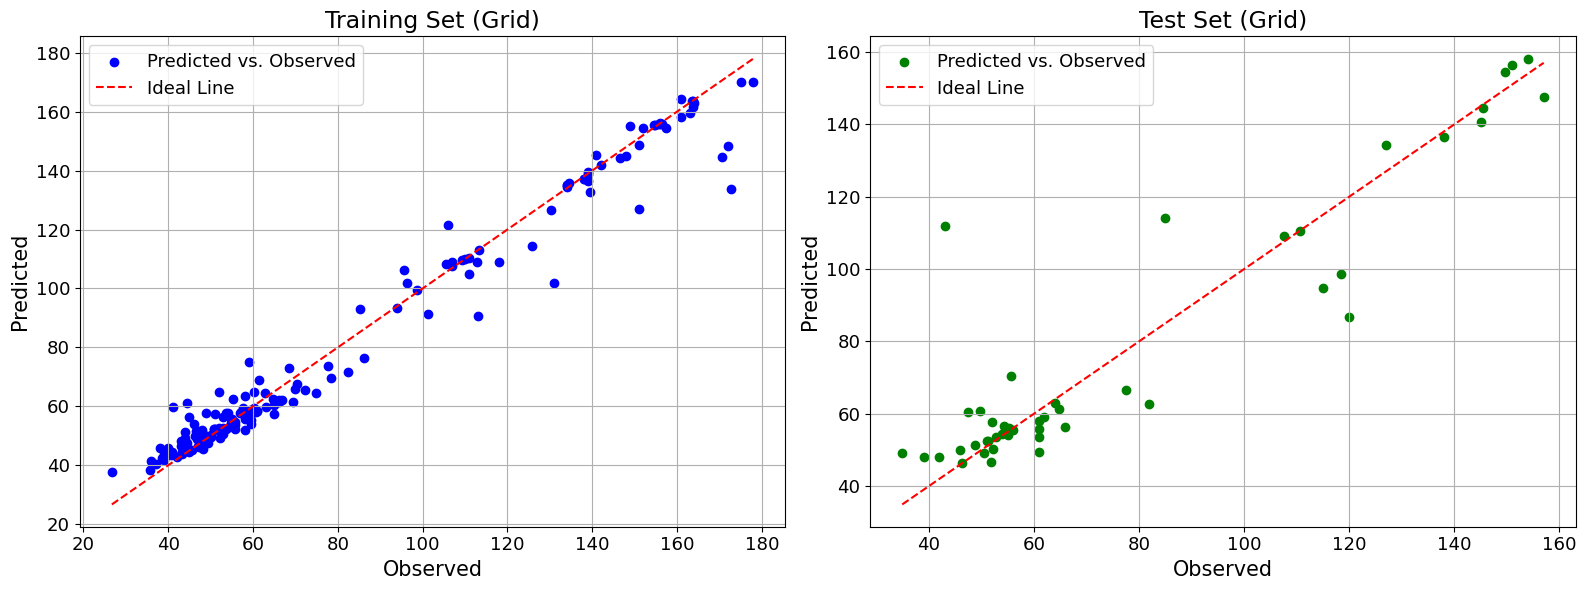

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed', fontsize=15)
axes[0].set_ylabel('Predicted', fontsize=15)
axes[0].set_title('Training Set (Grid)', fontsize=17)
axes[0].legend(fontsize=13)
axes[0].tick_params(axis='both', labelsize=13)
axes[0].grid(True)

# Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed', fontsize=15)
axes[1].set_ylabel('Predicted', fontsize=15)
axes[1].set_title('Test Set (Grid)', fontsize=17)
axes[1].legend(fontsize=13)
axes[1].tick_params(axis='both', labelsize=13)
axes[1].grid(True)

plt.tight_layout()
plt.savefig("mcl_tm_rf_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

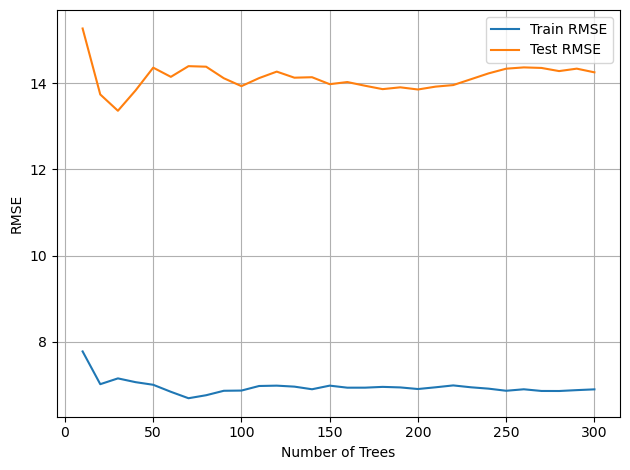

In [53]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("mcl_tm_rf_rmse.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [54]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

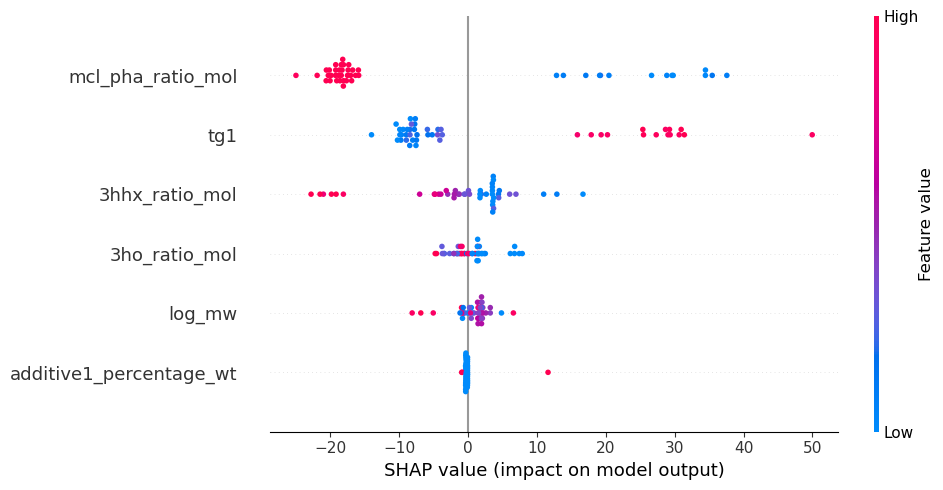

In [55]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("mcl_tm_rf_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [51]:
# Define the parameter grid
param_grid = {
     'n_estimators': [100, 200], # 100, 200, 300],
    'learning_rate': [0.05],
    'max_depth': [2, 4],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
     'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 5, 10],
}


folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100, reg_alpha=0, reg_lambda=5, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, n_estimators=100

## Plot results

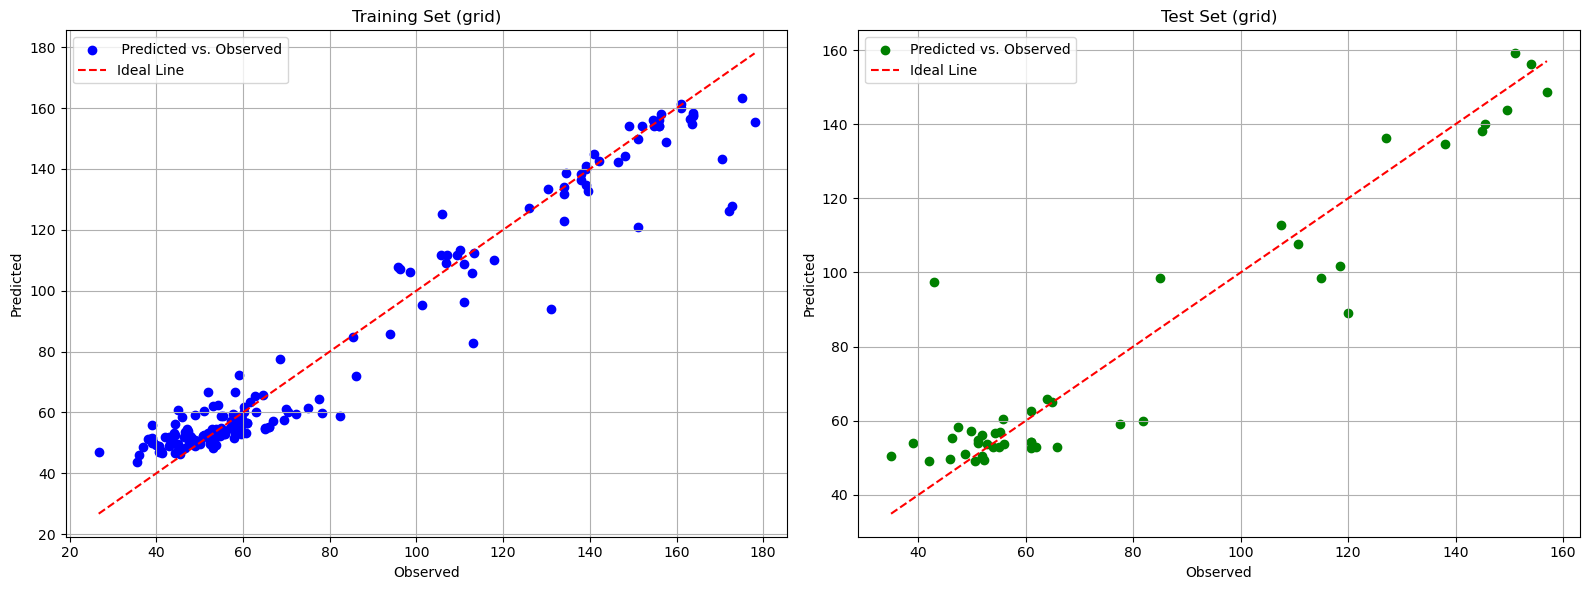

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("mcl_tm_xg_pair_grid.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

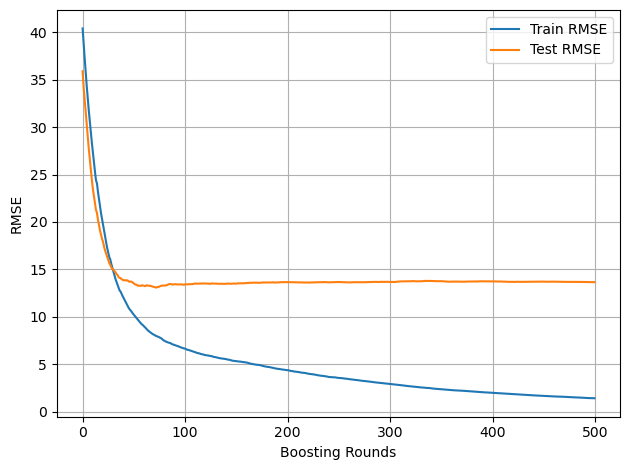

In [57]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("mcl_tm_xg_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [58]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

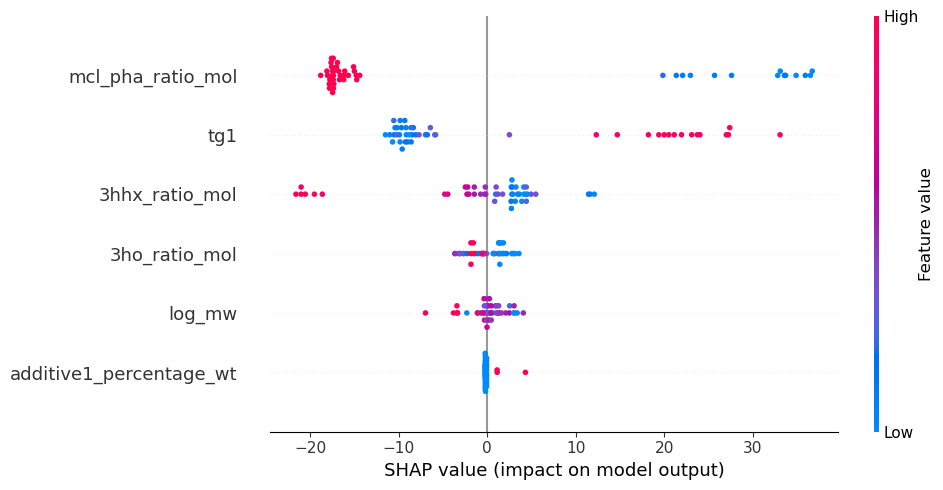

In [59]:
shap.summary_plot(
    shap_values2,
    X_test_final,
#    max_display=5,        # <-- top 10 features only
    show=False,
    plot_size=(10, 5)
)

plt.tight_layout()
plt.savefig("mcl_tm_xg_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Jaqpot

In [105]:
df_test.columns

Index(['scl_pha_ratio_mol', '3hb_ratio_mol', '3hv_ratio_mol',
       'mcl_pha_ratio_mol', '3hhx_ratio_mol', '3hhp_ratio_mol',
       '3ho_ratio_mol', '3hn_ratio_mol', '3hd_ratio_mol', '3hud_ratio_mol',
       '3hdd_ratio_mol', '3htrid_ratio_mol', '3httd_ratio_mol',
       'unsaturated_monomer_ratio_mol', 'mw', 'mn', 'pdi', 'additive1_type',
       'additive1_percentage_wt', 'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'tg1', 'tm1',
       'crystallinity_percentage', 'tm', 'tm_max'],
      dtype='object')

In [123]:
df_test = df_test.rename(columns={"3ho_ratio_mol": "ratio_3ho_mol","3hhx_ratio_mol":"ratio_3hhx_mol" })

In [124]:
features = [
#    'scl_pha_ratio_mol',
    'mcl_pha_ratio_mol',
#    'additive1_type',
    'additive1_percentage_wt',
 #   '3hb_ratio_mol',
    'ratio_3hhx_mol',
    'mw',
    'ratio_3ho_mol',
    'tg1'
]

target = 'tm'

measure_unit = 'Celcius'

In [125]:
# Create DataFrame
df_new = df_test[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]].copy()
# df_final[target] = np.log10(df_final[target])  # log-transform
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

In [126]:
# Separate features and target
drop_cols = [target]

X = df_final.drop(columns=drop_cols)
y = df_final[target]

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (208, 6) 
 Test set size (37, 6)


In [128]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

In [129]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [130]:
df_train = X_train.copy()
df_train[target] = y_train

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [131]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [132]:
model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0,
    reg_lambda=5,
)


jaqpot_model = XGBoostModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=preprocessing,
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.9476706092260172, 'mae': 6.36868064220135, 'rmse': 9.119763585564007}


In [133]:
from sklearn.base import clone

# Manually create what fit() should have set
jaqpot_model.unfit_pipeline = clone(jaqpot_model.pipeline)

# Now this should work
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.8194865184409631,
 'mae': 10.025749637276785,
 'rmse': 14.787048307313933}

In [134]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.8150695451639669, 'mae': 10.31924737466348, 'rmse': 18.9886784962593}

In [135]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.5557717143833434,
   'mae': 21.139892765191885,
   'rmse': 26.571363759721194},
  'Test': {'r2': -0.11737056883973618,
   'mae': 35.638663540401964,
   'rmse': 46.67551693212518}},
 'iteration_1': {'Train': {'r2': 0.562343673014652,
   'mae': 21.217577091363758,
   'rmse': 26.374081653281756},
  'Test': {'r2': -0.2491584012179655,
   'mae': 39.64080102044183,
   'rmse': 49.35137747782046}},
 'iteration_2': {'Train': {'r2': 0.521698117591976,
   'mae': 22.040173860696648,
   'rmse': 27.5715883554542},
  'Test': {'r2': -0.2221076319042401,
   'mae': 35.860263544031085,
   'rmse': 48.814095961354894}},
 'iteration_3': {'Train': {'r2': 0.5729836867694862,
   'mae': 20.635293554892904,
   'rmse': 26.05151438656492},
  'Test': {'r2': -0.15607614802385017,
   'mae': 36.84528840348527,
   'rmse': 47.477051841630676}},
 'iteration_4': {'Train': {'r2': 0.6275268388963897,
   'mae': 18.08062044950632,
   'rmse': 24.33090332666037},
  'Test': {'r2': -0.3258626064

In [136]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.02720237272352837, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.19594173474913798, 'hStar': 0.10096153846153846, 'inDoa': False}, {'h': 0.014905207801060093, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.01698581841155856, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.11240991960605885, 'hStar': 0.10096153846153846, 'inDoa': False}, {'h': 0.014357775529624327, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.016042716770907364, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.012150288662766361, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.003670030105191923, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.005775261235306373, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.025965208818804805, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.022901751258687077, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.01086123500168618, 'hStar': 0.10096153846153846, 'inDoa': True}, {'h': 0.013883999385022218,

In [137]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 37, 'n_in': 34, 'n_out': 3},
 'BOUNDING_BOX': {'n_total': 37, 'n_in': 37, 'n_out': 0}}

In [138]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Melting Temperature regression model for mcl-PHAs A.N.I.P.H.",
    description="Prediction of Melting Temperature for mcl-PHAs.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-14 22:15:40,967 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2399


In [139]:
df_train[features_num].agg(['min','max'])

,mcl_pha_ratio_mol,additive1_percentage_wt,ratio_3hhx_mol,mw,ratio_3ho_mol,tg1
min,0.0,0.0,0.0,13265.0,0.0,-53.0
max,104.0,48.0,100.0,2680000.0,100.0,15.3
